<a href="https://colab.research.google.com/github/princevp2006-source/synent-task5-salesanalysis-prince/blob/main/intermediate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv('train.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [3]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [4]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [10]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')

In [12]:
df['Month_Year'] = df['Order Date'].dt.to_period('M')

In [13]:
monthly_sales= df.groupby('Month_Year')['Sales'].sum()

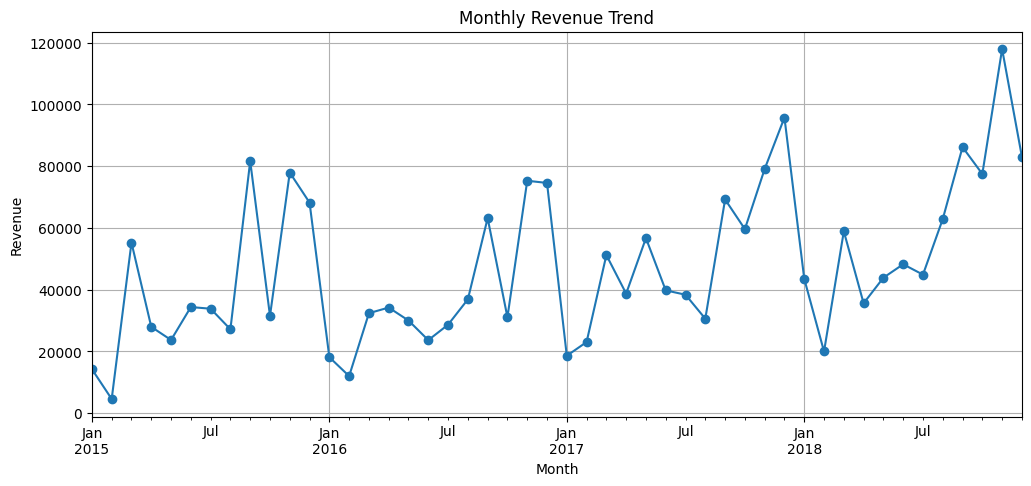

In [18]:
# Plot Monthly Revenue Trend
plt.figure(figsize=(12,5))
monthly_sales.plot(marker='o')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.grid(True)
plt.show()



Top 10 Selling Products:
Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


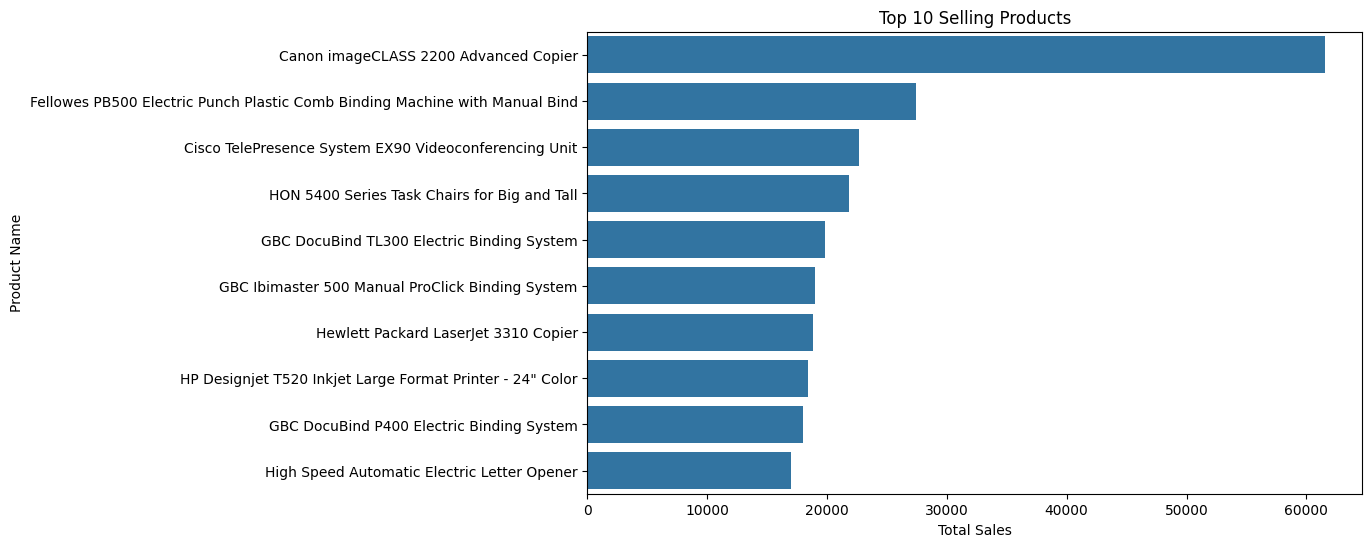

In [21]:
# 2. Top-Selling Products

top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

print("\nTop 10 Selling Products:")
print(top_products)

plt.figure(figsize=(10,6))
sns.barplot(x=top_products.values, y=top_products.index)
plt.title('Top 10 Selling Products')
plt.xlabel('Total Sales')
plt.ylabel('Product Name')
plt.show()

In [32]:
print(df.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']


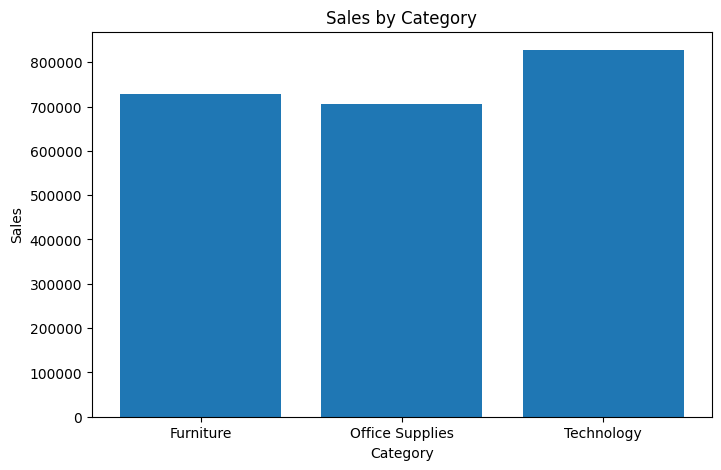

In [34]:
sales_by_category = df.groupby('Category')['Sales'].sum()

plt.figure(figsize=(8,5))
plt.bar(sales_by_category.index, sales_by_category.values)
plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Sales')
plt.show()


Top 10 Profitable Products:
Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


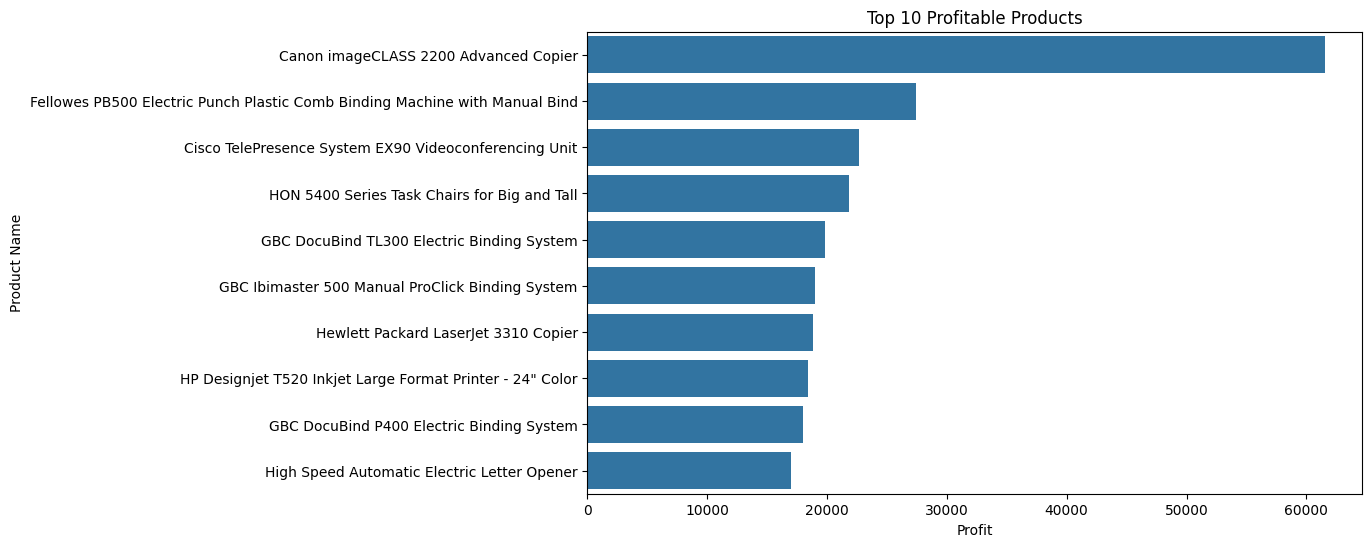

In [40]:
# most profitable products
top_profit_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

print("\nTop 10 Profitable Products:")
print(top_profit_products)

plt.figure(figsize=(10,6))
sns.barplot(x=top_profit_products.values, y=top_profit_products.index)
plt.title('Top 10 Profitable Products')
plt.xlabel('Profit')
plt.ylabel('Product Name')
plt.show()


Least Profitable Products:
Product Name
Eureka Disposable Bags for Sanitaire Vibra Groomer I Upright Vac    1.624
Avery 5                                                             5.760
Xerox 20                                                            6.480
Grip Seal Envelopes                                                 7.072
Acme Serrated Blade Letter Opener                                   7.632
Avery Hi-Liter Pen Style Six-Color Fluorescent Set                  7.700
Avery Hi-Liter Comfort Grip Fluorescent Highlighter, Yellow Ink     7.800
Xerox 1989                                                          7.968
4009 Highlighters                                                   8.040
Stockwell Gold Paper Clips                                          8.096
Name: Sales, dtype: float64


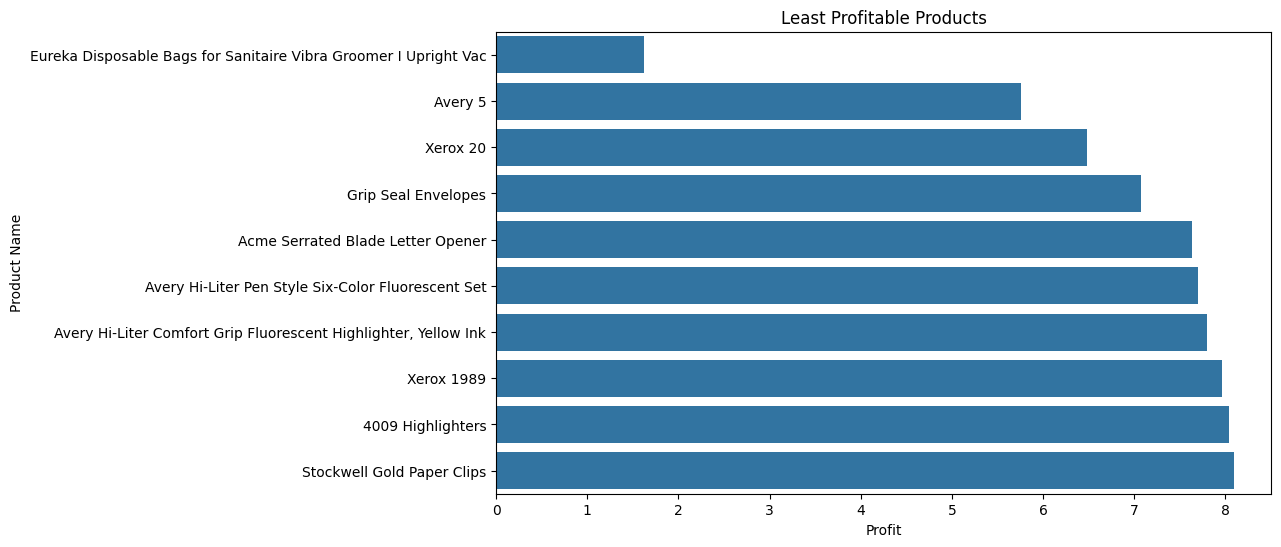

In [39]:
# Least Profitable Products

least_profit_products = df.groupby('Product Name')['Sales'].sum().sort_values().head(10)

print("\nLeast Profitable Products:")
print(least_profit_products)

plt.figure(figsize=(10,6))
sns.barplot(x=least_profit_products.values, y=least_profit_products.index)
plt.title('Least Profitable Products')
plt.xlabel('Profit')
plt.ylabel('Product Name')
plt.show()


In [42]:
print("\n----- BUSINESS INSIGHTS -----")

print("1. Highest Monthly Revenue:",
      monthly_sales.idxmax(),
      "Revenue =", round(monthly_sales.max(),2))

print("2. Best Selling Product:",
      top_products.idxmax(),
      "Sales =", round(top_products.max(),2))

print("3. Total Profit Generated:",
      round(sales_by_category,2))

print("4. Most Profitable Category:",
      sales_by_category.idxmax(),
      "Profit =", round(sales_by_category.max(),2))

print("5. Least Profitable Category:",
      sales_by_category.idxmin(),
      "Profit =", round(sales_by_category.min(),2))


----- BUSINESS INSIGHTS -----
1. Highest Monthly Revenue: 2018-11 Revenue = 117938.15
2. Best Selling Product: Canon imageCLASS 2200 Advanced Copier Sales = 61599.82
3. Total Profit Generated: Category
Furniture          728658.58
Office Supplies    705422.33
Technology         827455.87
Name: Sales, dtype: float64
4. Most Profitable Category: Technology Profit = 827455.87
5. Least Profitable Category: Office Supplies Profit = 705422.33
